In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

import os

df = pd.read_csv( 
    r"C:\Users\91934\OneDrive\Desktop\DA\ZDIP\data\cleaned\cleaned_movies.csv"
)

In [11]:
columns = ["Revenue", "Genre_Count", "Production_Company_Count"]

df[columns].describe()

,Revenue,Genre_Count,Production_Company_Count
count,4.067000e+03,4803.000000,4803.000000
mean,1.043237e+08,2.565064,3.209452
std,1.748430e+08,1.004200,1.991407
min,1.300000e+01,0.000000,0.000000
25%,1.144172e+07,2.000000,2.000000
50%,4.140000e+07,3.000000,3.000000
75%,1.204534e+08,3.000000,4.000000
max,2.923706e+09,7.000000,17.000000


In [12]:
for col in columns:
    print(f"{col} median:", df[col].median())

Revenue median: 41400000.0
Genre_Count median: 3.0
Production_Company_Count median: 3.0


In [13]:
for col in columns:
    print(f"{col} skewness:", df[col].skew())

Revenue skewness: 4.37767853990672
Genre_Count skewness: 0.3046061930548046
Production_Company_Count skewness: 1.4030041100531603


### Distribution Analysis

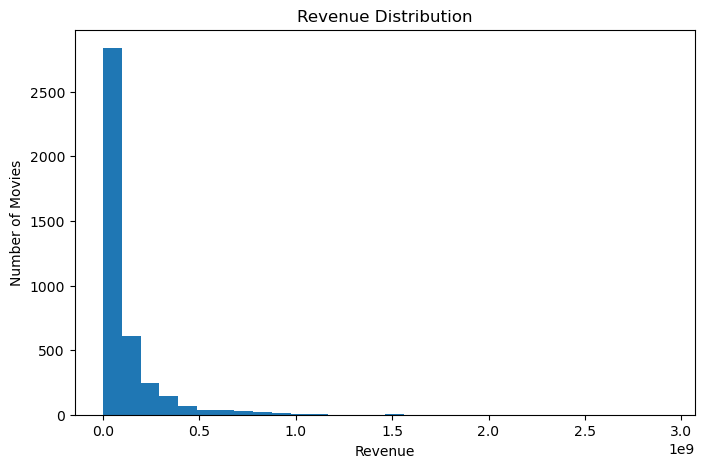

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Revenue"], bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")

plt.show()

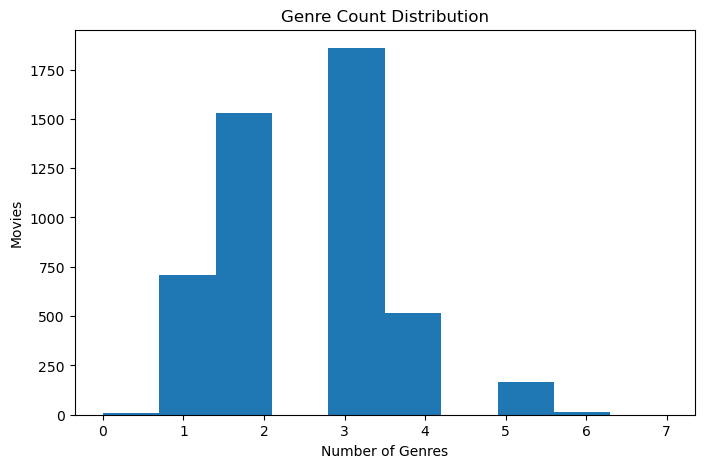

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["Genre_Count"], bins=10)

plt.title("Genre Count Distribution")
plt.xlabel("Number of Genres")
plt.ylabel("Movies")

plt.show()

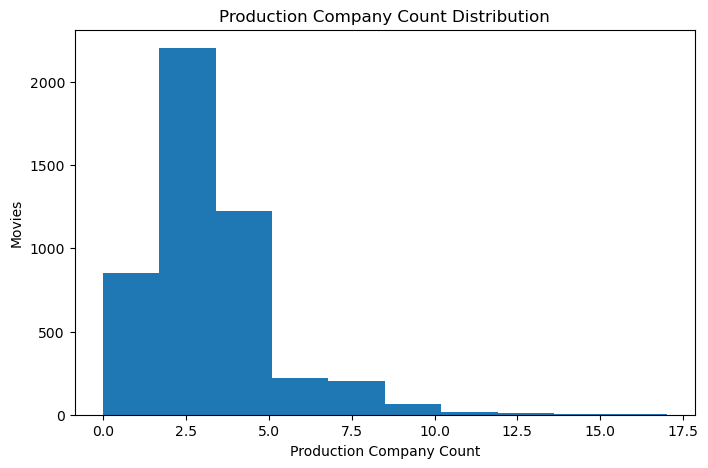

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["Production_Company_Count"], bins=10)

plt.title("Production Company Count Distribution")
plt.xlabel("Production Company Count")
plt.ylabel("Movies")

plt.show()

### Segment Analysis

In [17]:
top_companies = (
    df.groupby("Primary_Production_Company")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_companies)

Primary_Production_Company
Paramount Pictures       2.849472e+10
Universal Pictures       2.298636e+10
Warner Bros. Pictures    2.063190e+10
Columbia Pictures        1.855960e+10
Walt Disney Pictures     1.667987e+10
New Line Cinema          1.454833e+10
DreamWorks Animation     1.104955e+10
Marvel Studios           1.024026e+10
20th Century Fox         1.014176e+10
Pixar                    9.854925e+09
Name: Revenue, dtype: float64


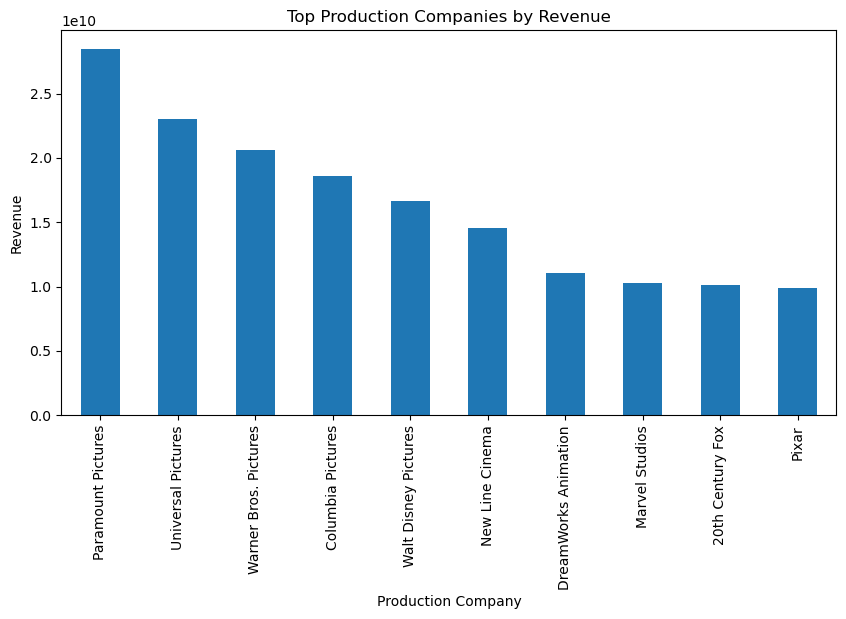

In [18]:
top_companies.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Production Companies by Revenue")
plt.xlabel("Production Company")
plt.ylabel("Revenue")

plt.show()

In [19]:
gender_analysis = (
    df.groupby("Cast_Gender_Ratio")["Revenue"]
    .agg(["count", "mean", "sum"])
)

print(gender_analysis)

                   count          mean          sum
Cast_Gender_Ratio                                  
0.00                  13  1.776790e+07  230982727.0
0.10                   1  7.269360e+05     726936.0
0.12                   0           NaN          0.0
0.14                   2  1.247199e+08  249439844.0
0.15                   1  3.741000e+08  374100000.0
...                  ...           ...          ...
29.00                  1  2.132162e+08  213216216.0
31.00                  1  5.075000e+07   50750000.0
33.00                  1  1.729897e+08  172989651.0
36.00                  1  8.980000e+07   89800000.0
38.00                  1  7.070000e+07   70700000.0

[308 rows x 3 columns]


### Date Features

In [ ]:
df["Release_Year"] = df["Release_Date"].dt.year

In [ ]:
df["Release_Month"] = df["Release_Date"].dt.month

In [ ]:
df["Release_Month_Name"] = df["Release_Date"].dt.month_name()

In [ ]:
df["Release_Quarter"] = df["Release_Date"].dt.quarter

In [ ]:
df["Release_Season"] = df["Release_Date"].dt.quarter

In [35]:
df[[
    "Release_Date",
    "Release_Year",
    "Release_Month",
    "Release_Month_Name",
    "Release_Quarter",
    "Release_Season"
]].head(10)

,Release_Date,Release_Year,Release_Month,Release_Month_Name,Release_Quarter,Release_Season
0,16-12-2009,2009,12.0,December,Q4,Winter
1,19-05-2007,2007,5.0,May,Q2,Spring
2,26-10-2015,2015,10.0,October,Q4,Autumn
3,17-07-2012,2012,7.0,July,Q3,Summer
4,07-03-2012,2012,3.0,March,Q1,Spring
5,01-05-2007,2007,5.0,May,Q2,Spring
6,24-11-2010,2010,11.0,November,Q4,Autumn
7,22-04-2015,2015,4.0,April,Q2,Spring
8,15-07-2009,2009,7.0,July,Q3,Summer
9,23-03-2016,2016,3.0,March,Q1,Spring
